# **Concrete Strength Prediction**

## Author: Ridwan Ademola, IBRAHIM  
## Dataset link: https://www.kaggle.com/datasets/mchilamwar/predict-concrete-strength

---

### **Structure of Study**
- ✅ **Phase 1:** Data Cleaning  
- ✅ **Phase 2:** Exploratory Data Analysis
- ✅ **Phase 3:** Feature Engineering   
- ✅ **Phase 4:** Classical Machine Learning  
- ✅ **Phase 5:** Deep Learning  


### **Phase 1:** Data Cleaning
- ✅ Structure Checks  
- ✅ Missing Values
- ✅ Duplicates  
- ✅ Outliers Diagnostics  

**Import the Required Libraries**

In [5]:
#import pandas, numpy, matplotlib, seaborn and stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats

from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

#set seaborn style to "whitegrid."
sns.set(style = "whitegrid")

In [6]:
#Load the csv file into a DataFrame and view the first few datapoints
df = pd.read_csv("concrete_data.csv")

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [7]:
#Peep further into the data by checking the shape, null rows, datatypes, and general information
df.shape
df.isnull().sum()

df.dtypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [8]:
#Check the statistical summary of the dataframe
df.describe()


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
#Check duplicate observations and drop them
df.duplicated().sum()
df = df.drop_duplicates()

#check shape of dataframe
df.shape

# Reset index after dropping
df = df.reset_index(drop = True)

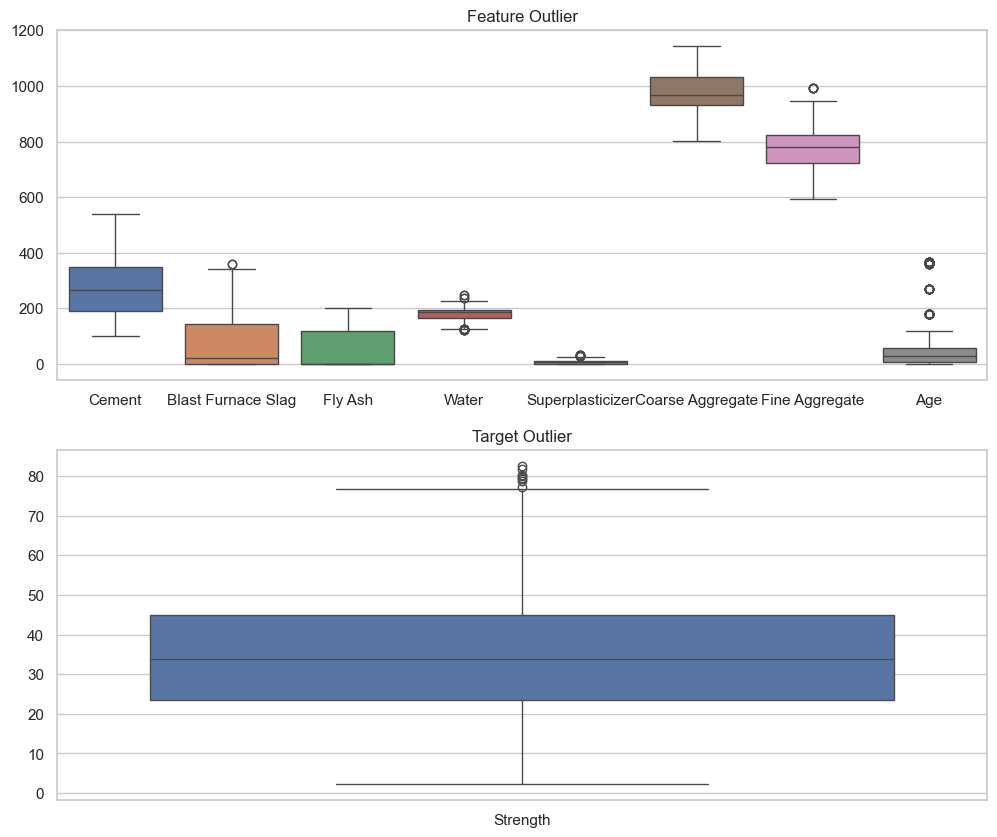

In [10]:
#Boxplot visualization for outliers
X = df.drop(columns = "Strength")
y = df[["Strength"]]

fig, ax = plt.subplots(2,1, figsize = (12,10))
sns.boxplot(data = X, ax = ax[0])
ax[0].set_title("Feature Outlier")

sns.boxplot(data = y, ax = ax[1])
ax[1].set_title("Target Outlier")

plt.show()

In [11]:
#Use the IQR Method to segregate the outliers
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

lower_outlier = (X < Q1 -1.5*IQR).sum()
upper_outlier = (X > Q3 +1.5*IQR).sum()

outlier = (lower_outlier + upper_outlier)
outlier.sum()

#remove outlier
X_clean = X[~ ((X < Q1 -1.5*IQR)  | (X > Q3 +1.5*IQR)).any(axis = 1)]
y_clean = y.loc[X_clean.index]
y_clean.head()

#concatenate X and y into a dataframe
clean_data = pd.concat([X_clean, y_clean], axis = 1)


#reset index
clean_data = clean_data.reset_index(drop = True)
clean_data.head()

clean_data.shape

(919, 9)

In [12]:
#Use Z-Score Method
clean_data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
3,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
4,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85


In [13]:
data = [540, 540, 266, 380, 266]
mean_value = np.mean(data)
std_value = np.std(data)

z_score = (data-mean_value)/std_value
z_score


array([ 1.15233056,  1.15233056, -1.07746163, -0.14973787, -1.07746163])

In [14]:
z_score = np.abs(stats.zscore(X))
z_score

outlier = (z_score > 3).sum()
outlier.sum()

49

### **Phase 2:** Exploratory Data Analysis
- ✅ Understand relationships between features and Strength
- ✅ Detect linear & nonlinear dependencies
- ✅ Detect multicollinearity 
- ✅ Identify most important predictors  

In [15]:
#Split cleaned data into X and y
df = clean_data
X = df.drop(columns = "Strength")
y = df["Strength"]

In [16]:
#Check skewness of the features
X.skew().sort_values(ascending=False)

Age                   1.259133
Blast Furnace Slag    0.819367
Cement                0.587340
Fly Ash               0.380721
Superplasticizer      0.324577
Water                 0.047865
Coarse Aggregate     -0.132846
Fine Aggregate       -0.282837
dtype: float64

In [17]:
#check Kurtosis of features
X.kurtosis().sort_values(ascending=False)

Age                   0.644785
Fine Aggregate       -0.043315
Water                -0.167639
Cement               -0.382661
Coarse Aggregate     -0.563093
Blast Furnace Slag   -0.568253
Superplasticizer     -0.647342
Fly Ash              -1.451343
dtype: float64

**Univariate Distribution**

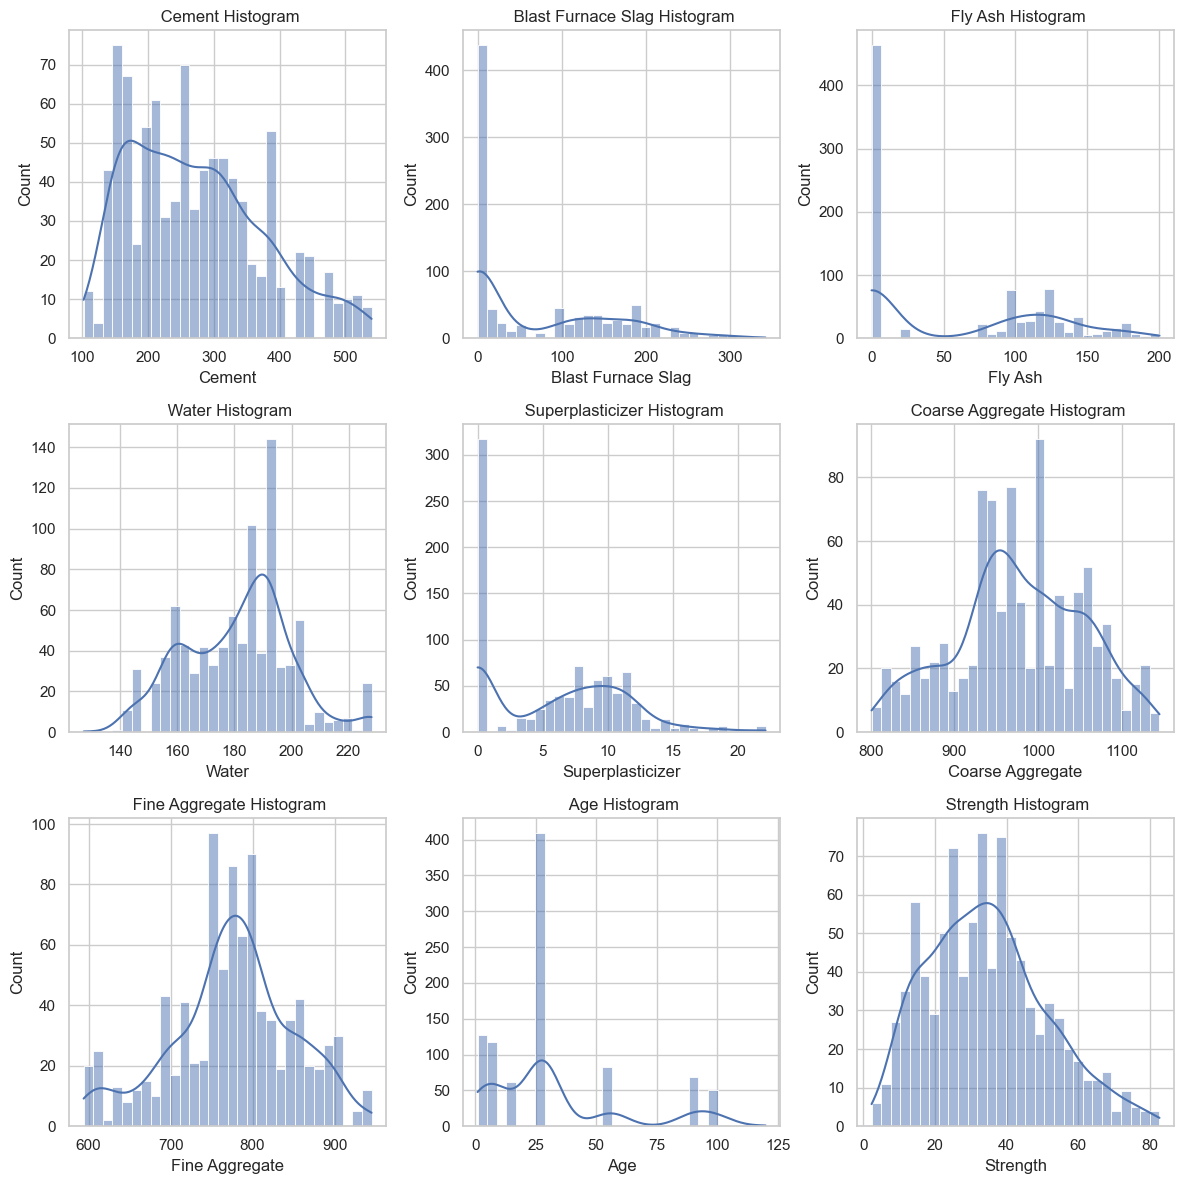

In [18]:
#plot the histogram distribution of each column (features and target)
fig, ax = plt.subplots(3,3, figsize = (12,12))
ax = ax.flatten()

for i, v in enumerate(df.columns):
    sns.histplot(df[v], kde = True, bins = 30, ax = ax[i])
    ax[i].set_title(f" {v} Histogram")

plt.tight_layout()
plt.show()


**Bivariate Distribution**

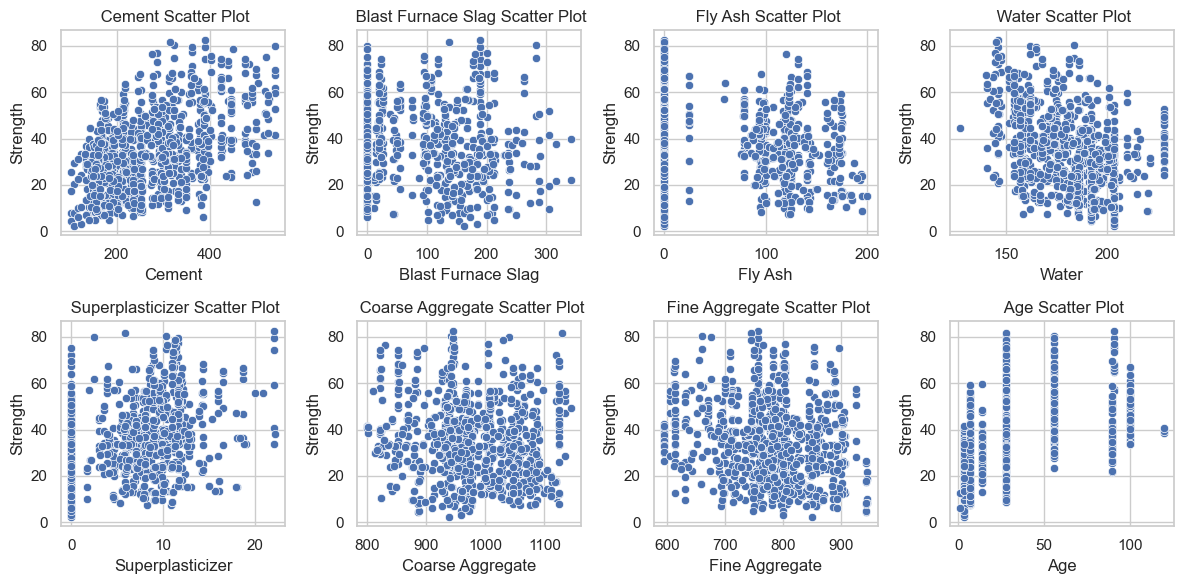

In [19]:
#Make a scatter plot of each feature against the target

fig, ax = plt.subplots(2,4, figsize = (12,6))
ax = ax.flatten()

for i, v in enumerate(X.columns):
    sns.scatterplot(x = X[v], y = y, ax = ax[i])
    ax[i].set_title(f" {v} Scatter Plot")

plt.tight_layout()
plt.show()

**Correlations**

In [20]:
#Linear Correlation, i.e., Pearson
pearson_corr = df.corr(method = "pearson")
pearson_corr

#Single out feature against target
pearson_corr["Strength"]

#Arrange in descending order
pearson_corr = pearson_corr["Strength"].sort_values(ascending=False)
pearson_corr

Strength              1.000000
Age                   0.516410
Cement                0.466214
Superplasticizer      0.377372
Blast Furnace Slag    0.114485
Fly Ash              -0.031152
Coarse Aggregate     -0.135282
Fine Aggregate       -0.185967
Water                -0.355078
Name: Strength, dtype: float64

In [21]:
# Monotonic correlation i.e Spearman
spearman_corr = df.corr(method = "spearman")
spearman_corr

#Single out feature against target
spearman_corr["Strength"]

#Arrange in descending order
spearman_corr = spearman_corr["Strength"].sort_values(ascending=False)
spearman_corr

Strength              1.000000
Age                   0.617619
Cement                0.439487
Superplasticizer      0.370091
Blast Furnace Slag    0.148949
Fly Ash               0.000201
Coarse Aggregate     -0.142701
Fine Aggregate       -0.190643
Water                -0.350714
Name: Strength, dtype: float64

In [22]:
# Rank-based correlation i.e Kendall
kendall_corr = df.corr(method = "kendall")
kendall_corr

#Single out feature against target
kendall_corr["Strength"]

#Arrange in descending order
kendall_corr = kendall_corr["Strength"].sort_values(ascending=False)
kendall_corr

Strength              1.000000
Age                   0.474587
Cement                0.300179
Superplasticizer      0.264922
Blast Furnace Slag    0.108581
Fly Ash              -0.002136
Coarse Aggregate     -0.095526
Fine Aggregate       -0.128987
Water                -0.237546
Name: Strength, dtype: float64

In [23]:
#concatenate the three plots 
overall_corr = pd.concat([pearson_corr,spearman_corr,  kendall_corr], axis = 1)

overall_corr

#rename columns
overall_corr.columns = [" Pearson Strength", "Spearman Strength", "Kendall Strength"]
overall_corr

,Pearson Strength,Spearman Strength,Kendall Strength
Strength,1.000000,1.000000,1.000000
Age,0.516410,0.617619,0.474587
Cement,0.466214,0.439487,0.300179
Superplasticizer,0.377372,0.370091,0.264922
Blast Furnace Slag,0.114485,0.148949,0.108581
Fly Ash,-0.031152,0.000201,-0.002136
Coarse Aggregate,-0.135282,-0.142701,-0.095526
Fine Aggregate,-0.185967,-0.190643,-0.128987
Water,-0.355078,-0.350714,-0.237546


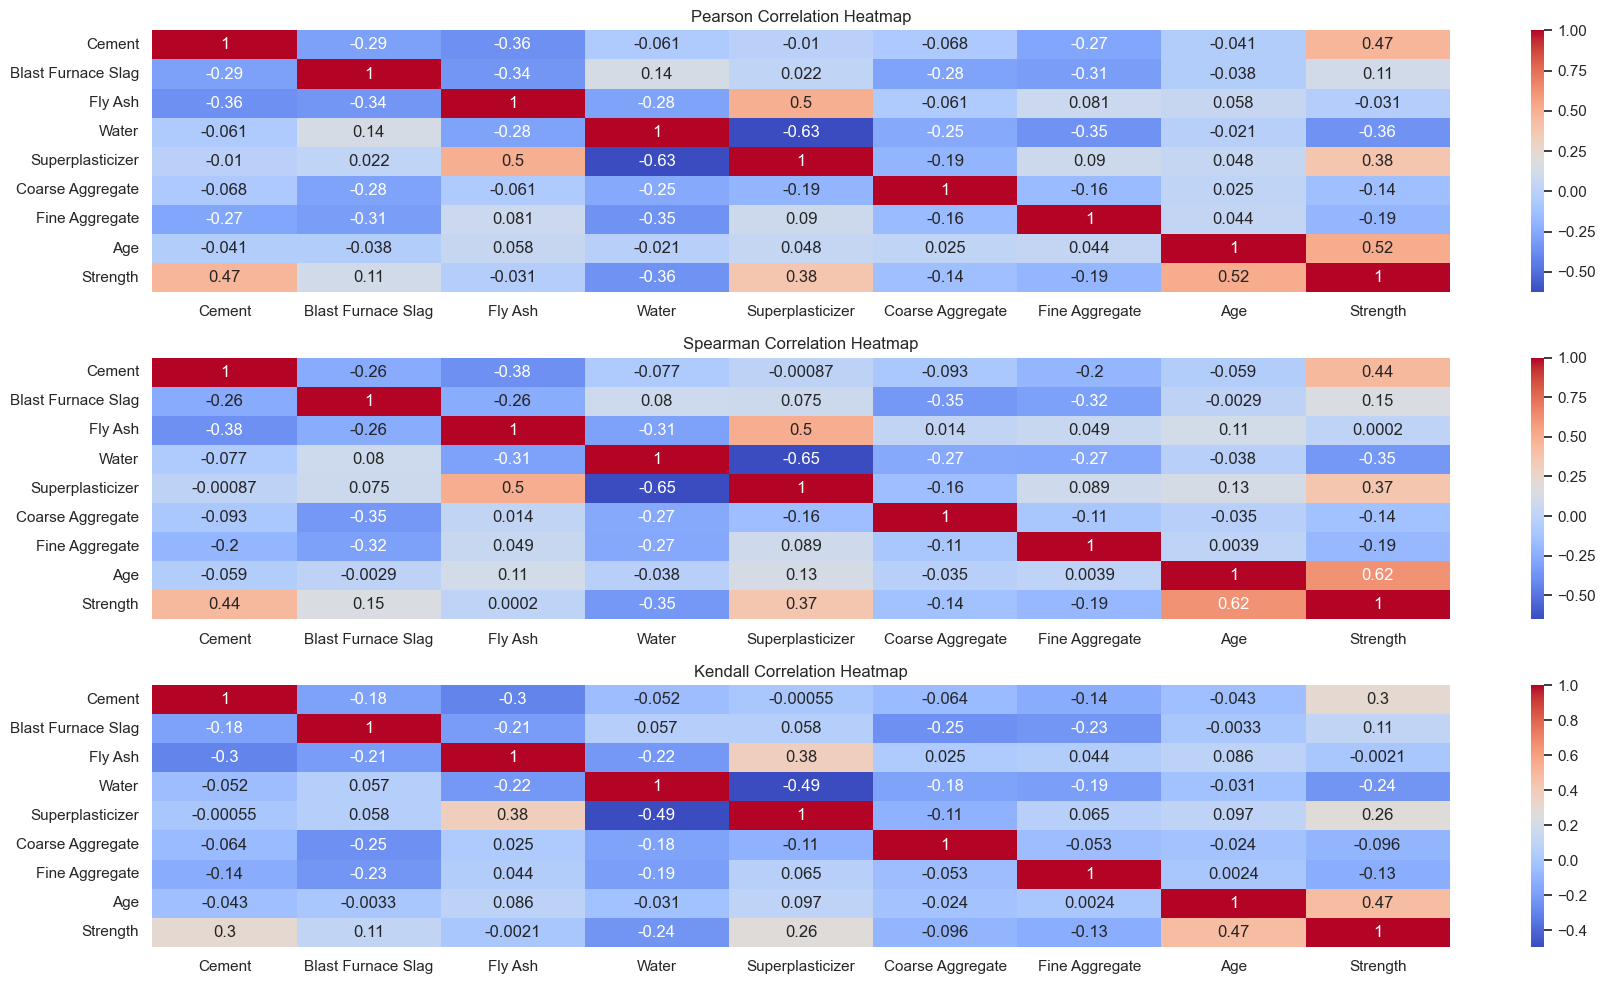

In [24]:
#Make a heatmap for correlation as a form of visualization
fig, ax = plt.subplots(3, 1, figsize = (18, 10))

sns.heatmap(data = df.corr(method = "pearson"), ax = ax[0], cmap = "coolwarm", annot = True, cbar = True)
ax[0].set_title("Pearson Correlation Heatmap")

sns.heatmap(data = df.corr(method = "spearman"), ax = ax[1], cmap = "coolwarm", annot = True, cbar = True)
ax[1].set_title("Spearman Correlation Heatmap")

sns.heatmap(data = df.corr(method = "kendall"), ax = ax[2], cmap = "coolwarm", annot = True, cbar = True)
ax[2].set_title("Kendall Correlation Heatmap")


plt.tight_layout()
plt.show()


**Information Theory: Mutual Information**

In [25]:
# Compute mutual information
mi_scores = mutual_info_regression(X, y)
mi_scores


# Convert to pandas Series
mi = pd.Series(data = mi_scores, index=X.columns)
mi = mi.sort_values(ascending = False)


# Sort values
mi.plot(kind = "bar");


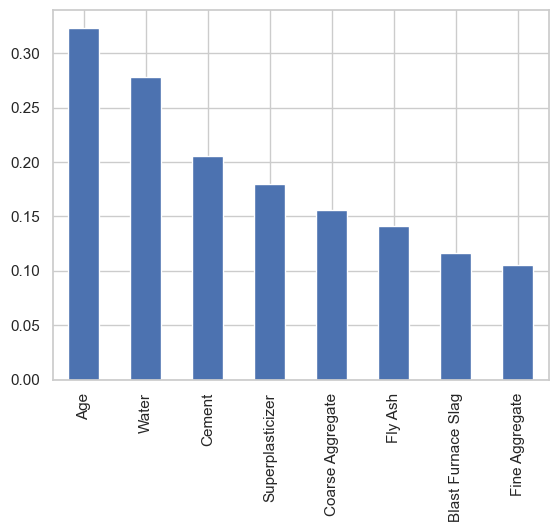

In [26]:
#Visualize the mutual information
mi.plot(kind = "bar");


In [34]:
#split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [84]:
#Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
#initialize the model
model = LinearRegression()

In [76]:
#train - fit data to model
model = model.fit(X_train_scaled,y_train)

In [77]:
#make predictions
y_pred = model.predict(X_test_scaled)

In [78]:
#calculate mse
mse = mean_squared_error(y_pred, y_test)
mse

70.03961594483539

In [79]:
#calculate mae
mae = mean_absolute_error(y_pred, y_test)
mae

6.409115734133303

In [80]:
#calculate rmse
rmse = root_mean_squared_error(y_pred, y_test)
rmse

8.368967436000418

In [81]:
#calculate r2
r_square= r2_score(y_pred, y_test)
r_square

0.6655434852070947

In [82]:
#put all metrics in a list
result = []

result.append(mse)
result.append(mae)
result.append(rmse)
result.append(r_square)
result

[70.03961594483539, 6.409115734133303, 8.368967436000418, 0.6655434852070947]

In [83]:
#put all metrics in a dictionary
result_dict = {}

result_dict["mse error"] = mse
result_dict["mae error"] = mae
result_dict["rmse error"] = rmse
result_dict["r-square error"] = r_square

result_dict

{'mse error': 70.03961594483539,
 'mae error': 6.409115734133303,
 'rmse error': 8.368967436000418,
 'r-square error': 0.6655434852070947}

In [85]:
#Create a function for reusability

#create a dictionary to put all models
All_model = {}

#create the function
def evaluation_model(model, X_train_scaled, X_test_scaled, y_train, y_test, model_name):

    #fit data to model
    model = model.fit(X_train_scaled,y_train)

    #make predictions
    y_pred = model.predict(X_test_scaled)

    #metrics
    mse = mean_squared_error(y_pred, y_test)
    mae = mean_absolute_error(y_pred, y_test)
    rmse = root_mean_squared_error(y_pred, y_test)
    r_square= r2_score(y_pred, y_test)

    #Put the metrics in a dictionary and then append it to all model dictionary
    All_model[model_name] = {
        "mse error": mse,
        "mae error": mae,
        "rmse error": rmse,
        "r-square error": r_square
    }

    #return the current model
    return All_model[model_name]

In [86]:
#try Linear Model
lin_model = LinearRegression()

lin_model = evaluation_model(lin_model, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression")
lin_model

{'mse error': 70.03961594483539,
 'mae error': 6.409115734133303,
 'rmse error': 8.368967436000418,
 'r-square error': 0.6655434852070947}

In [87]:
#Check all models dictionary
All_model

{'Linear Regression': {'mse error': 70.03961594483539,
  'mae error': 6.409115734133303,
  'rmse error': 8.368967436000418,
  'r-square error': 0.6655434852070947}}

In [93]:
X = np.arange(0,31,1.5)
Y = [0, 9.76, 13.01, 11.39, 6.51, 0, -6.51, -11.39, -13.01, -9.76, 0, -4.56, -6.62, -6.64, -5.11, -2.49, 0.71, 4.05, 7.02, 9.16, 9.98]

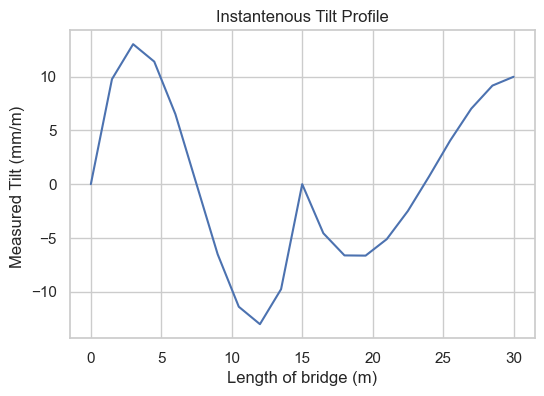

In [97]:
plt.figure(figsize = (6,4))
plt.plot(X,Y)
plt.xlabel("Length of bridge (m)")
plt.ylabel("Measured Tilt (mm/m) ")
plt.title("Instantenous Tilt Profile")
plt.show()